# Regressão Linear com PyTorch

## Objetivos

Este exemplo utiliza regressão linear para estimar o comprimento das sépalas da íris a partir do seu comprimento das pétalas.
Utiliza-se:
- a função de perda MSE do PyTorch,
- treinamento dos parâmetros via gradiente descendente usando o otimizador.
- A rede é criada com uma camada nn.Linear()

## Importação dos pacotes

In [13]:
# http://pytorch.org/
!pip install torch torchvision torchaudio
import torch

In [2]:
%matplotlib inline
import torch
from torch import nn, optim
from torch.autograd import Variable
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

torch.manual_seed(1234)

## Leitura dos dados

In [3]:
iris = load_iris()
data = iris.data[iris.target==1,::2]  # comprimento das sépalas e pétalas, indices 0 e 2

x_train = data[:,0:1].astype(np.float32)
y_train = data[:,1:2].astype(np.float32)

n_samples = x_train.shape[0]
print('x_train.shape:',x_train.shape, x_train.dtype)
print('y_train.shape:',y_train.shape, y_train.dtype)

print('x_train[:5]:\n', x_train[:5])
print('y_train[:5]:\n', y_train[:5])

x_train.shape: (50, 1) float32
y_train.shape: (50, 1) float32
x_train[:5]:
 [[7. ]
 [6.4]
 [6.9]
 [5.5]
 [6.5]]
y_train[:5]:
 [[4.7]
 [4.5]
 [4.9]
 [4. ]
 [4.6]]


### Normalização dos dados

In [4]:
x_train -= x_train.min()
x_train /= x_train.max()
y_train -= y_train.min()
y_train /= y_train.max()


In [5]:
x_train_bias = np.hstack([np.ones(shape=(n_samples,1)), x_train])

In [6]:
x_train_bias = torch.FloatTensor(x_train_bias)
y_train      = torch.FloatTensor(y_train)

## Criação do modelo da rede

In [7]:
model = torch.nn.Linear(2, 1, bias=False)

### Verificando a inicialização dos parâmetros

In [8]:
model.weight.data = torch.zeros(1,2)
torch.nn.init.uniform(model.weight.data, -0.1, 0.1)
model.weight.data

/tmp/ipython-input-1486225639.py:2: FutureWarning: `nn.init.uniform` is now deprecated in favor of `nn.init.uniform_`.
  torch.nn.init.uniform(model.weight.data, -0.1, 0.1)


tensor([[-0.0480, -0.0267]])

### Testando o predict da rede

In [9]:
model(Variable(torch.ones((5,2))))

tensor([[-0.0747],
        [-0.0747],
        [-0.0747],
        [-0.0747],
        [-0.0747]], grad_fn=<MmBackward0>)

## Treinamento

### Definindo função de perda e otimizador

In [14]:
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.3)

### Laço de treinamento

In [17]:
num_epochs = 120
w0_list = []
w1_list = []
for epoch in range(num_epochs):
    inputs = Variable(x_train_bias)
    target = Variable(y_train)

    # forward - predict
    out = model(inputs)

    w0_list.append(model.weight.data[0][0].item())
    w1_list.append(model.weight.data[0][1].item())

    #loss cálculo da função de perda
    loss = criterion(out, target)

    # backward e otimizador
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # verbose
    if (epoch+1) % 20 == 0:
        print('Epoch[{}/{}], loss: {:.6f}'
              .format(epoch+1, num_epochs, loss.item()))

Epoch[20/120], loss: 0.021291
Epoch[40/120], loss: 0.021208
Epoch[60/120], loss: 0.021182
Epoch[80/120], loss: 0.021173
Epoch[100/120], loss: 0.021171
Epoch[120/120], loss: 0.021170


## Avaliação

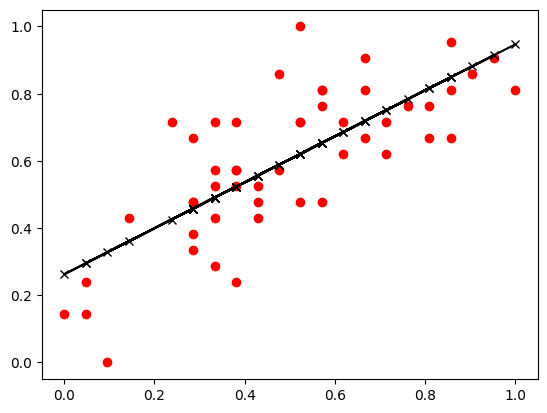

In [18]:
y_pred = model(Variable(x_train_bias))
plt.plot(x_train, y_train.numpy(), 'ro', label='Original data')
plt.plot(x_train, y_pred.data.numpy(), 'kx-', label='Fitting Line')
plt.show()

In [ ]:
y_pred = model(Variable(x_train_bias))
loss = criterion(y_pred, Variable(y_train))
print(loss)

# Exercícios

- 1) Calcule o valor da função de custo (MSE) depois da rede treinada, utilizando a
   função `criterion` utilizada no laço de treinamento.

In [20]:
# calculando o valor da função de custo (perda) com o uso do criterion:

with torch.no_grad():
  predictions = model(Variable(x_train_bias))
  final_mse = criterion(predictions, Variable(y_train))
  print("Função MSE após o treinasmento: ",final_mse.item())

Função MSE após o treinasmento:  0.021169792860746384


- 2) Faça igual o exercício do notebook anterior, de plotar um gráfico scatterplot para
   mostrar a evolução dos parâmetros durante o treinamento pelo gradiente descendente.

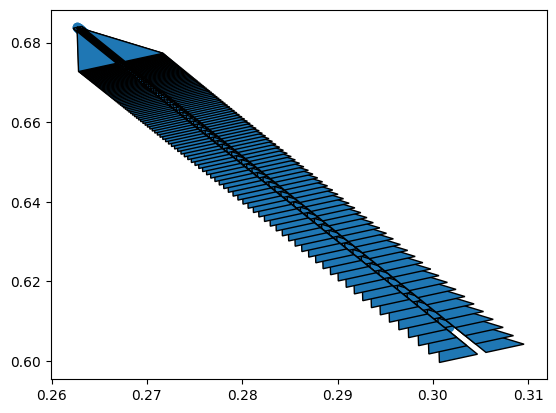

In [24]:
plt.scatter(w0_list,w1_list)
w0_old = None
for (w0,w1) in zip(w0_list,w1_list):
    if w0_old:
        plt.arrow(w0_old, w1_old, w0-w0_old, w1-w1_old,
                  head_length=0.01,head_width=0.01,shape='full',
                  length_includes_head=True)
    w0_old,w1_old = w0,w1

- 3) Procure sobrepor a função de perda neste gráfico. (exercício mais difícil).

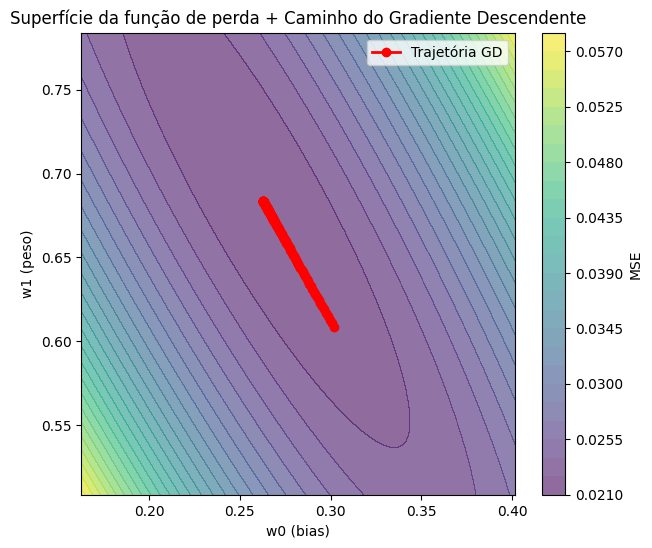

In [23]:
# 3. Sobrepor a função de perda (MSE) no gráfico

# Criando uma grade de valores para w0 e w1
w0_range = torch.linspace(min(w0_list)-0.1, max(w0_list)+0.1, 80)
w1_range = torch.linspace(min(w1_list)-0.1, max(w1_list)+0.1, 80)

W0, W1 = torch.meshgrid(w0_range, w1_range, indexing='ij')

Z = torch.zeros_like(W0)

# Para cada ponto da grade, calcula o MSE
for i in range(W0.shape[0]):
    for j in range(W0.shape[1]):
        w = torch.tensor([[W0[i,j], W1[i,j]]], dtype=torch.float32)
        y_pred_grid = x_train_bias.mm(w.T)
        Z[i,j] = ((y_train - y_pred_grid)**2).mean()

# Plotando o mapa de calor da função de perda
plt.figure(figsize=(7,6))
cs = plt.contourf(W0, W1, Z, levels=30, alpha=0.6)
plt.colorbar(cs, label="MSE")

# Sobrepondo o caminho dos pesos treinando
plt.plot(w0_list, w1_list, color='red', marker='o', linewidth=2, label='Trajetória GD')

plt.xlabel("w0 (bias)")
plt.ylabel("w1 (peso)")
plt.title("Superfície da função de perda + Caminho do Gradiente Descendente")
plt.legend()
plt.show()



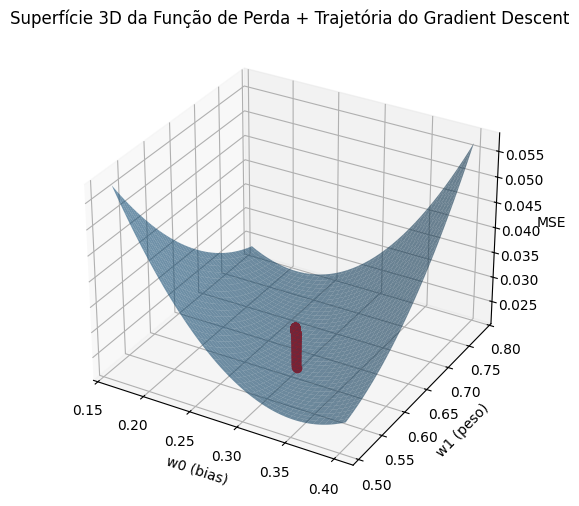

In [25]:
# adicionando uma superfície 3D do MSE (função perda):

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(W0.numpy(), W1.numpy(), Z.numpy(), alpha=0.6)

# Trajetória dos pesos sobre a superfície
ax.plot(w0_list, w1_list,
        [((y_train - x_train_bias @ torch.tensor([[w0, w1]]).T)**2).mean().item() for w0,w1 in zip(w0_list,w1_list)],
        color='red', marker='o')

ax.set_xlabel('w0 (bias)')
ax.set_ylabel('w1 (peso)')
ax.set_zlabel('MSE')
ax.set_title('Superfície 3D da Função de Perda + Trajetória do Gradient Descent')
plt.show()


KeyboardInterrupt: 

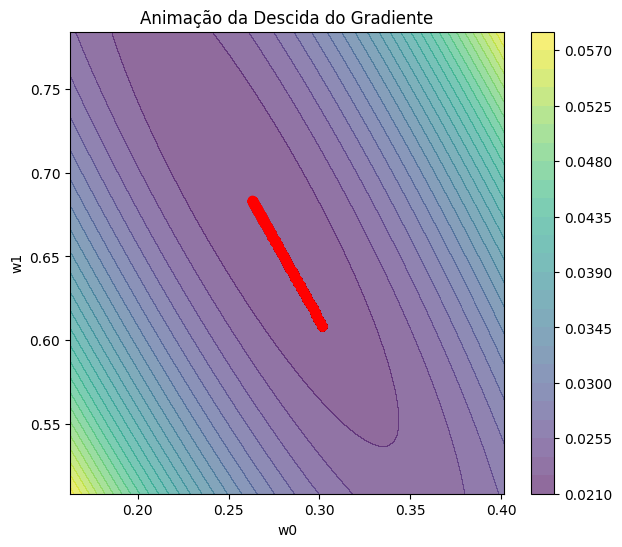

In [28]:
# adicionando também uma aanimação frame a frame do gradiente descendo:

import time
from IPython import display

plt.figure(figsize=(7,6))
cs = plt.contourf(W0, W1, Z, levels=30, alpha=0.6)
plt.colorbar(cs)
plt.xlabel("w0")
plt.ylabel("w1")
plt.title("Animação da Descida do Gradiente")

for i in range(len(w0_list)):
    plt.plot(w0_list[:i+1], w1_list[:i+1], color='red', marker='o')
    display.clear_output(wait=True)
    display.display(plt.gcf())
    time.sleep(0.1)

# Aprendizados

##### Durante este exercício, foi possível entender de forma prática como funciona o processo de ajuste de parâmetros em um modelo de regressão linear utilizando gradiente descendente.
Ao longo do treinamento, o modelo atualizou os valores dos pesos w0 (bias) e
w1 (peso) para minimizar o erro entre as previsões e os valores reais.

Acompanhando a lista de valores de w0 e w1 a cada época, foi possível visualizar a trajetória desses pesos até o ponto onde o erro se torna mínimo. Isso ficou evidente no gráfico que mostra o caminho percorrido no espaço dos parâmetros.

Além disso, ao sobrepor a função de perda (MSE) no mesmo gráfico, ficou mais claro que o gradiente descendente funciona como uma “descida em direção ao fundo de uma tigela”, onde o fundo representa o ponto de menor erro.
Essa visualização ajuda a entender que o modelo não “adivinha” os pesos ideais: ele vai ajustando passo a passo, sempre seguindo a direção onde o erro diminui.

Por fim, o gráfico interativo 3D reforçou essa ideia ao mostrar a superfície da função de perda e o caminho exato percorrido. Isso contribuiu para uma compreensão mais intuitiva de como o modelo aprende, tornando o conceito muito mais visual e concreto.